In [2]:
!pip install bertopic sentence-transformers pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 12.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util

# ==========================================
# 1. CARGAR EL DATASET
# ==========================================
print("Cargando el dataset de comentarios...")
df_comentarios = pd.read_csv('df_comentarios_final.csv', encoding='utf-8-sig')

textos_positivos = df_comentarios['positivo'].fillna("").astype(str).tolist()
textos_negativos = df_comentarios['negativo'].fillna("").astype(str).tolist()

# ==========================================
# 2. CONFIGURAR LAS "SEMILLAS" AMPLIADAS
# ==========================================
print("Configurando las categorías objetivo ampliadas...")

# Lo ponemos como un Diccionario para asociar rápidamente el Título a sus palabras clave
diccionario_temas = {
    "Limpieza": "limpieza, suciedad, higiene, estado del baño, polvo, manchas, olores, limpio, sucio, impecable, sábanas sucias",
    "Confort": "confort, comodidad de las camas, tamaño de habitación, descanso, frío, caliente, calefacción, calor, aire acondicionado, temperatura, ruido, insonorización, silencioso, colchón, almohada",
    "WiFi": "conexión wifi, internet, cobertura, señal, velocidad, router, desconexión, red",
    "Personal": "atención del personal, amabilidad, trato en recepción, servicio, disposición, recepcionista, empleados, simpáticos, profesionales, bordes",
    "Instalaciones y Servicios": "instalaciones, piscina, gimnasio, restaurante, desayuno, comida, buffet, ascensor, spa, bar, terraza, zonas comunes",
    "Calidad/Precio": "relación calidad precio, coste, dinero, caro, barato, estafa, económico, tarifas, sobreprecio",
    "Ubicación": "ubicación, vistas, cerca del centro, transporte público, estacionamiento, parking, garaje, aparcamiento, barrio, zona, metro, autobús, céntrico, lejos"
}

nombres_categorias = list(diccionario_temas.keys())
descripciones_categorias = list(diccionario_temas.values())


# ==========================================
# 3. CARGAR EL MODELO TRANSFORMER
# ==========================================
print("Cargando el modelo Transformer multilingüe (MPNet)...")
modelo = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

# Convertimos nuestros 7 "párrafos semilla" a vectores matemáticos (solo se hace una vez)
embeddings_temas = modelo.encode(descripciones_categorias, convert_to_tensor=True)


# ==========================================
# 4. FUNCIÓN MÁGICA: ASIGNACIÓN MÚLTIPLE
# ==========================================
def asignar_temas_multiples(textos, umbral_similitud=0.35):
    # Convertimos todas las reseñas a vectores
    embeddings_textos = modelo.encode(textos, convert_to_tensor=True, show_progress_bar=True)

    # Comparamos matemáticamente cada reseña contra los 7 temas a la vez
    # Devuelve una matriz de notas de similitud de 0 a 1
    similitudes = util.cos_sim(embeddings_textos, embeddings_temas).cpu().numpy()

    resultados = []

    for fila_notas in similitudes:
        temas_encontrados = []
        # Revisamos la nota que ha sacado esta reseña en cada uno de los 7 temas
        for indice, nota in enumerate(fila_notas):
            if nota >= umbral_similitud:
                # Si supera el umbral, añadimos el nombre de la categoría
                temas_encontrados.append(nombres_categorias[indice])

        # Si encontró algo, los unimos con un guion. Si no, ponemos "Otro"
        if len(temas_encontrados) > 0:
            resultados.append(" - ".join(temas_encontrados))
        else:
            resultados.append("Otro Tema / Mixto / Vacío")

    return resultados

# ==========================================
# 5. ENTRENAMIENTO Y PREDICCIÓN (DOBLE)
# ==========================================
# El umbral_similitud = 0.35 es configurable.
# Si el modelo clasifica cosas que no son, súbelo a 0.40.
# Si se deja muchas reseñas en "Otro Tema", bájalo a 0.30.

print("🤖 Buscando temas múltiples en los comentarios POSITIVOS...")
df_comentarios['tema_positivo'] = asignar_temas_multiples(textos_positivos, umbral_similitud=0.35)

print("🤖 Buscando temas múltiples en las QUEJAS...")
df_comentarios['tema_negativo'] = asignar_temas_multiples(textos_negativos, umbral_similitud=0.35)


# ==========================================
# 6. EXPORTAR EL RESULTADO FINAL
# ==========================================
print("Guardando el nuevo CSV Multi-Tema...")

nombre_archivo_salida = 'df_comentarios_final_topics.csv'
df_comentarios.to_csv(nombre_archivo_salida, index=False, encoding='utf-8-sig')

print(f"✅ ¡Proceso completado con éxito! Archivo guardado como: {nombre_archivo_salida}")

# Comprobamos visualmente la magia
display(df_comentarios[['positivo', 'tema_positivo', 'negativo', 'tema_negativo']].head(15))

Cargando el dataset de comentarios...
Configurando las categorías objetivo ampliadas...
Cargando el modelo Transformer multilingüe (MPNet)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🤖 Buscando temas múltiples en los comentarios POSITIVOS...


Batches:   0%|          | 0/1835 [00:00<?, ?it/s]

🤖 Buscando temas múltiples en las QUEJAS...


Batches:   0%|          | 0/1835 [00:00<?, ?it/s]

Guardando el nuevo CSV Multi-Tema...
✅ ¡Proceso completado con éxito! Archivo guardado como: df_comentarios_final_topics_multi.csv


,positivo,tema_positivo,negativo,tema_negativo
0,espectacular todo! restaurante; servicio; habi...,Limpieza - Confort - Personal - Instalaciones ...,todo me gustó,Otro Tema / Mixto / Vacío
1,NaN,Otro Tema / Mixto / Vacío,NaN,Otro Tema / Mixto / Vacío
2,"habitaciones amplias, limpieza y ubicación",Limpieza - Confort - Personal - Instalaciones ...,NaN,Otro Tema / Mixto / Vacío
3,el trato en recepción,Personal - Instalaciones y Servicios,el estacionamiento,Instalaciones y Servicios - Ubicación
4,las vistas y el tamaño de la habitación.,Confort - Instalaciones y Servicios,"la calefacción central, sólo eso.",Limpieza - Confort
5,me encantó,Otro Tema / Mixto / Vacío,todo súper bien,Otro Tema / Mixto / Vacío
6,todo,Otro Tema / Mixto / Vacío,nada,Otro Tema / Mixto / Vacío
7,"nos encantó la habitación super espaciosa, cam...",Confort - Personal - Instalaciones y Servicios,NaN,Otro Tema / Mixto / Vacío
8,una limpieza impecable y el trato del personal...,Limpieza - Personal - Instalaciones y Servicios,NaN,Otro Tema / Mixto / Vacío
9,la habitación muy bonita y cómoda,Limpieza - Confort - Instalaciones y Servicios,NaN,Otro Tema / Mixto / Vacío


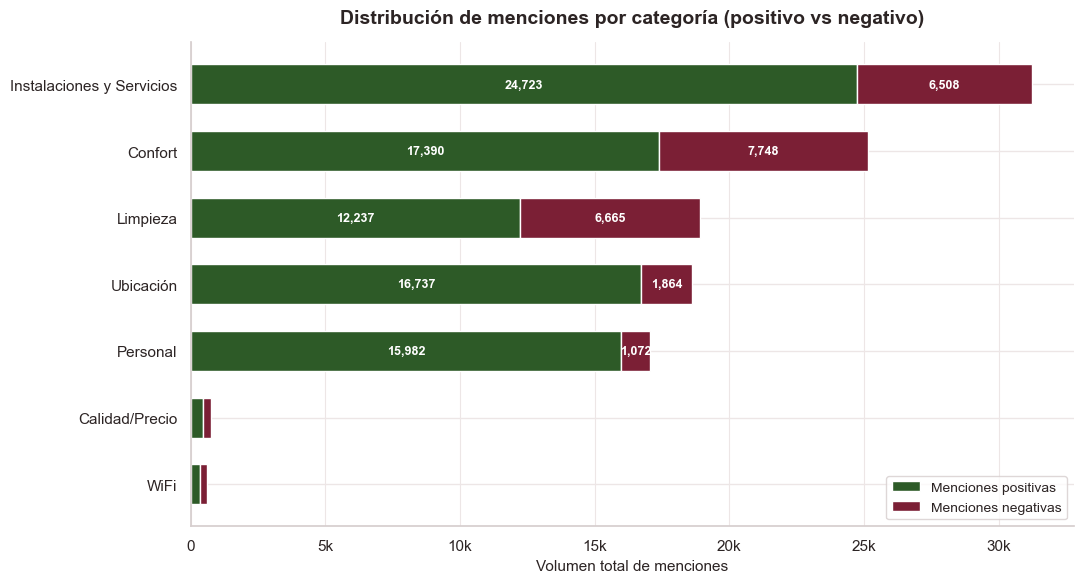

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# COLORES
# ==============================================================================
VERDE_OSCURO = '#2D5A27'   # verde bosque oscuro (positivo)
BURDEOS      = '#7B1F35'   # burdeos (negativo)

# ==============================================================================
# CARGA Y PREPARACIÓN
# ==============================================================================
df = pd.read_csv('datos/procesados/df_comentarios_final_topics.csv')

temas_pos = df['tema_positivo'].str.split(' - ').explode()
temas_neg = df['tema_negativo'].str.split(' - ').explode()

conteos_pos = (temas_pos[temas_pos != "Otro Tema / Mixto / Vacío"]
               .value_counts().rename('Menciones Positivas'))
conteos_neg = (temas_neg[temas_neg != "Otro Tema / Mixto / Vacío"]
               .value_counts().rename('Menciones Negativas'))

df_conteos = pd.concat([conteos_pos, conteos_neg], axis=1).fillna(0)
df_conteos['Total'] = df_conteos['Menciones Positivas'] + df_conteos['Menciones Negativas']
df_conteos = df_conteos.sort_values('Total', ascending=True).drop(columns=['Total'])

# ==============================================================================
# GRÁFICO
# ==============================================================================
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars_pos = ax.barh(df_conteos.index, df_conteos['Menciones Positivas'],
                   color=VERDE_OSCURO, height=0.6, label='Menciones positivas')
bars_neg = ax.barh(df_conteos.index, df_conteos['Menciones Negativas'],
                   left=df_conteos['Menciones Positivas'],
                   color=BURDEOS, height=0.6, label='Menciones negativas')

# Etiquetas dentro — solo si la barra es suficientemente ancha para no solaparse
UMBRAL = 600
for bar in bars_pos:
    w = bar.get_width()
    if w > UMBRAL:
        ax.text(bar.get_x() + w / 2, bar.get_y() + bar.get_height() / 2,
                f'{int(w):,}', ha='center', va='center',
                color='white', fontweight='bold', fontsize=9)

for bar, izquierda in zip(bars_neg, df_conteos['Menciones Positivas']):
    w = bar.get_width()
    if w > UMBRAL:
        ax.text(izquierda + w / 2, bar.get_y() + bar.get_height() / 2,
                f'{int(w):,}', ha='center', va='center',
                color='white', fontweight='bold', fontsize=9)

ax.set_title('Distribución de menciones por categoría (positivo vs negativo)',
             fontsize=14, fontweight='bold', pad=14, color='#2C2424')
ax.set_xlabel('Volumen total de menciones', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=11)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x)))
)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#D6CECE')
ax.grid(axis='x', color='#EDE6E6', linewidth=0.8)
ax.set_axisbelow(True)

ax.legend(loc='lower right', frameon=True, fontsize=10,
          facecolor='white', edgecolor='#D6CECE')

plt.tight_layout()
plt.savefig('grafico_barras_apiladas.png', dpi=150, bbox_inches='tight')
plt.show()